# Exploratory Data Analysis and Feature Engineering
## Life Expectancy Dataset

This project performs:
- Dataset understanding
- Data quality checking
- Missing-value analysis
- Duplicate detection
- Validity and range checking
- Univariate analysis
- Bivariate analysis
- Correlation analysis
- Outlier analysis
- Data cleaning
- Feature engineering
- Final validation

## Importing Libraries

In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load the dataset

In [104]:
df = pd.read_csv("Life Expectancy Data.csv")

### Data Samples

In [105]:
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [106]:
df.sample(5)

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
1059,Guatemala,2014,Developing,71.7,187.0,10,1.88,657.528280,73.0,0,...,65.0,6.20,73.0,0.4,3687.763767,15923559.0,1.2,1.2,0.614,10.7
99,Armenia,2012,Developing,74.4,121.0,1,3.89,274.152699,95.0,0,...,96.0,4.48,95.0,0.1,3684.848100,2881922.0,2.0,2.1,0.732,12.7
2316,Singapore,2012,Developed,82.5,59.0,0,1.89,6041.858981,97.0,42,...,97.0,4.22,97.0,0.1,54431.161990,NaN,2.2,2.1,0.917,15.4
2083,Qatar,2003,Developing,76.5,85.0,0,1.00,4049.972347,93.0,24,...,93.0,4.14,92.0,0.1,34176.981830,NaN,4.8,4.5,0.815,12.8
2543,Syrian Arab Republic,2009,Developing,73.8,124.0,7,0.81,0.000000,84.0,22,...,83.0,3.55,8.0,0.1,NaN,2824893.0,6.4,6.2,0.648,11.8


### Dataset Information

In [107]:
print(df.shape)
print("Rows: ",df.shape[0])
print("Columns: ",df.shape[1])

(2938, 22)
Rows:  2938
Columns:  22


#### The dataset contains 2938 rows and 22 columns

In [108]:
df.size

64636

In [109]:
df.columns

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='str')

In [110]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio                          

#### This identifies: * data types   * number of non-null values  * numerical columns  * categorical columns

In [111]:
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


#### This gives: * mean * standard deviation * minimum * quartiles * maximum

In [112]:
df.describe(include="object")

/var/folders/44/fywnm5sj335fdzvrq6s4_m3c0000gn/T/ipykernel_2040/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Country,Status
count,2938,2938
unique,193,2
top,Afghanistan,Developing
freq,16,2426


#### This shows the number of unique categories and the most frequent category for each categorical feature.

### Missing Values

In [113]:
missing = pd.DataFrame({"Missing_Count": df.isnull().sum(), "Missing_Percentage": (df.isnull().sum() / len(df)) * 100})
missing = missing.sort_values(by="Missing_Percentage", ascending=False)
missing

,Missing_Count,Missing_Percentage
Population,652,22.191967
Hepatitis B,553,18.822328
GDP,448,15.248468
Total expenditure,226,7.692308
Alcohol,194,6.603131
Income composition of resources,167,5.684139
Schooling,163,5.547992
thinness 5-9 years,34,1.157250
thinness 1-19 years,34,1.157250
BMI,34,1.157250


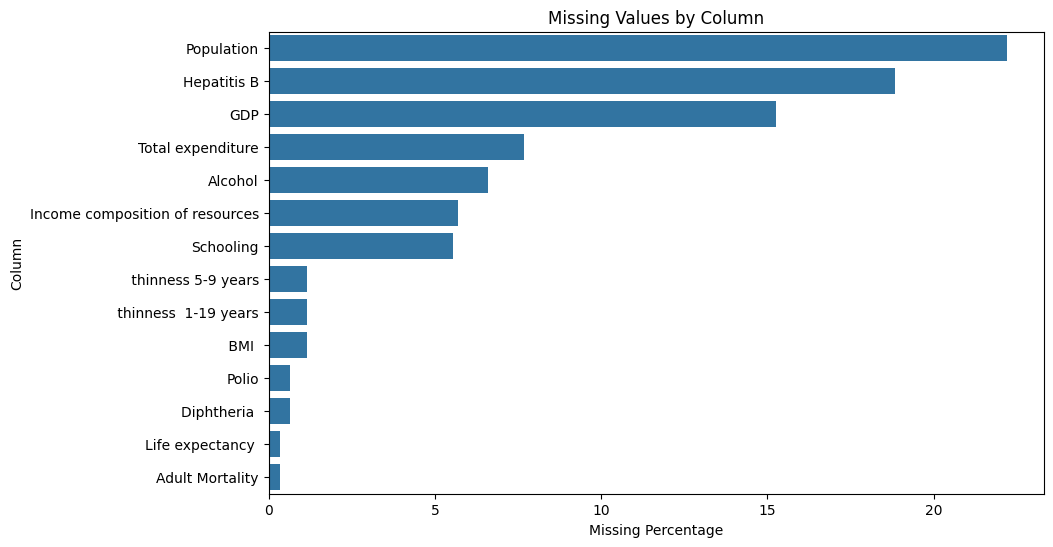

In [114]:
missing_plot = missing[missing["Missing_Count"] > 0]
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_plot["Missing_Percentage"], y=missing_plot.index)
plt.title("Missing Values by Column")
plt.xlabel("Missing Percentage")
plt.ylabel("Column")
plt.show()

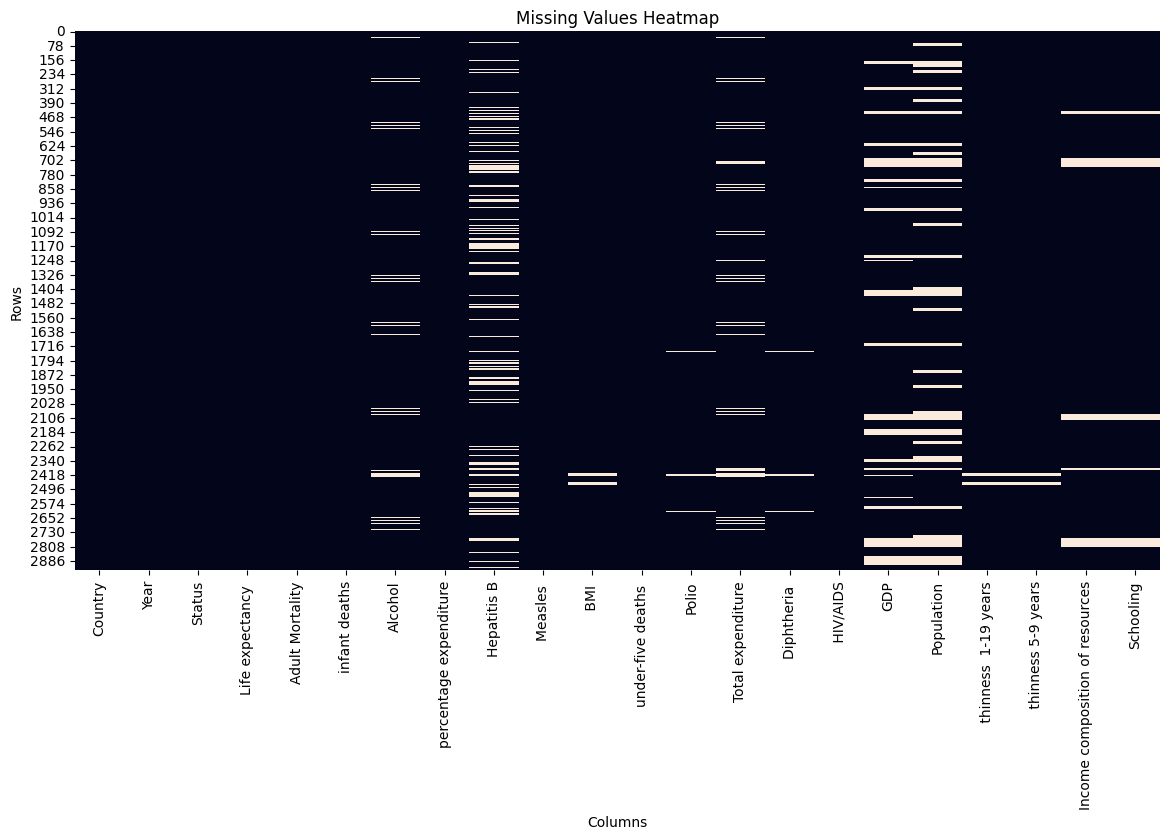

In [115]:
plt.figure(figsize=(14, 7))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

#### The heatmap makes it easier to see which columns contain missing data.

### Duplicate values

In [116]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


### Cleaning Columns Names

In [117]:
df.columns = (df.columns.str.strip() .str.lower() .str.replace(" ", "_") .str.replace("/", "_").str.replace("-","_"))

In [118]:
df.columns

Index(['country', 'year', 'status', 'life_expectancy', 'adult_mortality',
       'infant_deaths', 'alcohol', 'percentage_expenditure', 'hepatitis_b',
       'measles', 'bmi', 'under_five_deaths', 'polio', 'total_expenditure',
       'diphtheria', 'hiv_aids', 'gdp', 'population', 'thinness__1_19_years',
       'thinness_5_9_years', 'income_composition_of_resources', 'schooling'],
      dtype='str')

### Unique Values

In [119]:
df["country"].nunique()

193

#### The dataset have 193 different countries

In [120]:
df["year"].unique()

array([2015, 2014, 2013, 2012, 2011, 2010, 2009, 2008, 2007, 2006, 2005,
       2004, 2003, 2002, 2001, 2000])

#### Data is from 2000 to 2015

In [121]:
df["status"].value_counts()

status
Developing    2426
Developed      512
Name: count, dtype: int64

### Numerical Values

In [122]:
numeric_columns = df.select_dtypes(include=np.number).columns
numeric_columns

Index(['year', 'life_expectancy', 'adult_mortality', 'infant_deaths',
       'alcohol', 'percentage_expenditure', 'hepatitis_b', 'measles', 'bmi',
       'under_five_deaths', 'polio', 'total_expenditure', 'diphtheria',
       'hiv_aids', 'gdp', 'population', 'thinness__1_19_years',
       'thinness_5_9_years', 'income_composition_of_resources', 'schooling'],
      dtype='str')

In [123]:
negative_values = (df[numeric_columns] < 0).sum()
negative_values[negative_values > 0]

Series([], dtype: int64)

In [124]:
zero_values = (df[numeric_columns] == 0).sum()
zero_values[zero_values > 0].sort_values(ascending=False)

measles                            983
infant_deaths                      848
under_five_deaths                  785
percentage_expenditure             611
income_composition_of_resources    130
schooling                           28
dtype: int64

In [125]:
zero_as_missing = ["bmi", "gdp", "population"]
for column in zero_as_missing:
    df[column] = df[column].replace(0, np.nan)

In [126]:
df[zero_as_missing].isnull().sum()

bmi            34
gdp           448
population    652
dtype: int64

In [127]:
print(df["year"].min())
print(df["year"].max())

2000
2015


In [128]:
invalid_years = df[(df["year"] < 2000) | (df["year"] > 2015)]
invalid_years

,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,...,polio,total_expenditure,diphtheria,hiv_aids,gdp,population,thinness__1_19_years,thinness_5_9_years,income_composition_of_resources,schooling


In [129]:
df[(df["life_expectancy"] <= 0) | (df["life_expectancy"] > 120)]

,country,year,status,life_expectancy,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,...,polio,total_expenditure,diphtheria,hiv_aids,gdp,population,thinness__1_19_years,thinness_5_9_years,income_composition_of_resources,schooling


In [130]:
percentage_columns = ["hepatitis_b", "polio", "diphtheria"]
for column in percentage_columns:
    print(column, "min =", df[column].min(), "max =", df[column].max())

hepatitis_b min = 1.0 max = 99.0
polio min = 3.0 max = 99.0
diphtheria min = 2.0 max = 99.0


In [131]:
df["income_composition_of_resources"].describe()

count    2771.000000
mean        0.627551
std         0.210904
min         0.000000
25%         0.493000
50%         0.677000
75%         0.779000
max         0.948000
Name: income_composition_of_resources, dtype: float64

In [132]:
df["bmi"].describe()

count    2904.000000
mean       38.321247
std        20.044034
min         1.000000
25%        19.300000
50%        43.500000
75%        56.200000
max        87.300000
Name: bmi, dtype: float64

In [133]:
df["population"].describe()

count    2.286000e+03
mean     1.275338e+07
std      6.101210e+07
min      3.400000e+01
25%      1.957932e+05
50%      1.386542e+06
75%      7.420359e+06
max      1.293859e+09
Name: population, dtype: float64

In [134]:
df["gdp"].describe()

count      2490.000000
mean       7483.158469
std       14270.169342
min           1.681350
25%         463.935626
50%        1766.947595
75%        5910.806335
max      119172.741800
Name: gdp, dtype: float64

### Missing values handling

In [135]:
numeric_columns = df.select_dtypes(include=np.number).columns
for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

In [136]:
categorical_columns = df.select_dtypes(include="object").columns
for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

/var/folders/44/fywnm5sj335fdzvrq6s4_m3c0000gn/T/ipykernel_2040/3462832881.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


In [137]:
df.isnull().sum().sort_values(ascending=False)
print("Total missing values:",df.isnull().sum().sum())

Total missing values: 0


In [138]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


### Outliers

In [ ]:
numeric_columns = df.select_dtypes(include=np.number).columns
outlier_summary = []
for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_limit) | (df[column] > upper_limit)]
    outlier_summary.append([column, len(outliers), round((len(outliers) / len(df)) * 100, 2), lower_limit, upper_limit])
outlier_summary = pd.DataFrame(outlier_summary,
    columns=["Column", "Outlier Count", "Outlier Percentage", "Lower Limit", "Upper Limit"])
outlier_summary

,Column,Outlier Count,Outlier Percentage,Lower Limit,Upper Limit
0,year,0,0.00,1.992000e+03,2.024000e+03
1,life_expectancy,17,0.58,4.460000e+01,9.420000e+01
2,adult_mortality,86,2.93,-1.555000e+02,4.565000e+02
3,infant_deaths,315,10.72,-3.300000e+01,5.500000e+01
4,alcohol,3,0.10,-8.353750e+00,1.683625e+01
5,percentage_expenditure,389,13.24,-6.505879e+02,1.096807e+03
6,hepatitis_b,322,10.96,6.100000e+01,1.170000e+02
7,measles,542,18.45,-5.403750e+02,9.006250e+02
8,bmi,0,0.00,-3.565000e+01,1.111500e+02
9,under_five_deaths,394,13.41,-4.200000e+01,7.000000e+01


In [144]:
columns_to_cap = [
    "infant_deaths",
    "under_five_deaths",
    "gdp",
    "population",
    "hiv_aids",
    "measles"
]

In [145]:
for column in columns_to_cap:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower_limit, upper=upper_limit)

In [146]:
outlier_summary_after = []
for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_limit) | (df[column] > upper_limit)]
    outlier_summary_after.append([column, len(outliers)])
pd.DataFrame(outlier_summary_after, columns=["Column", "Remaining Outliers"])

,Column,Remaining Outliers
0,year,0
1,life_expectancy,17
2,adult_mortality,86
3,infant_deaths,0
4,alcohol,3
5,percentage_expenditure,389
6,hepatitis_b,322
7,measles,0
8,bmi,0
9,under_five_deaths,0


In [147]:
important_numeric = [
    "life_expectancy",
    "adult_mortality",
    "infant_deaths",
    "alcohol",
    "bmi",
    "under_five_deaths",
    "hiv_aids",
    "gdp",
    "population",
    "schooling"
]

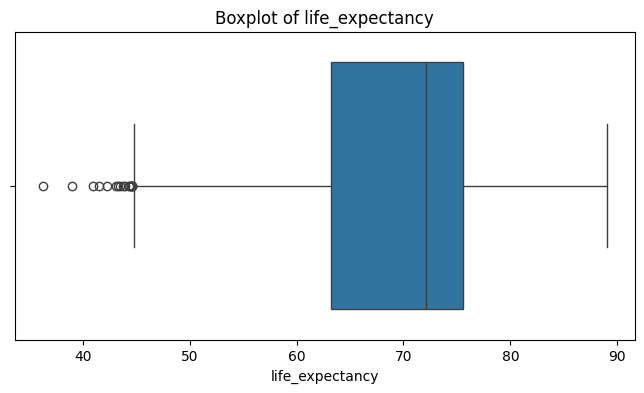

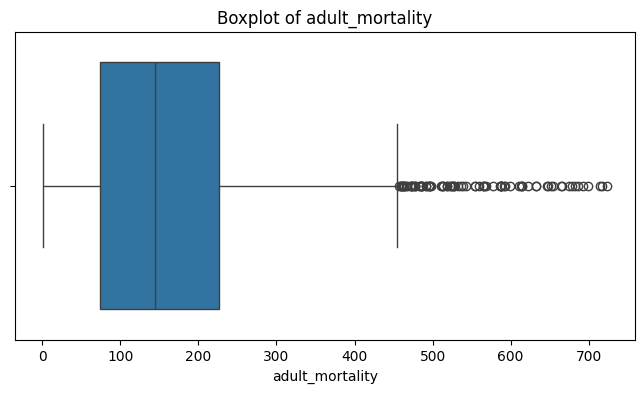

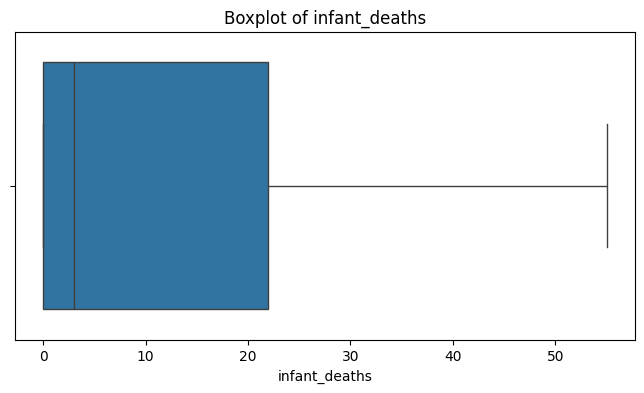

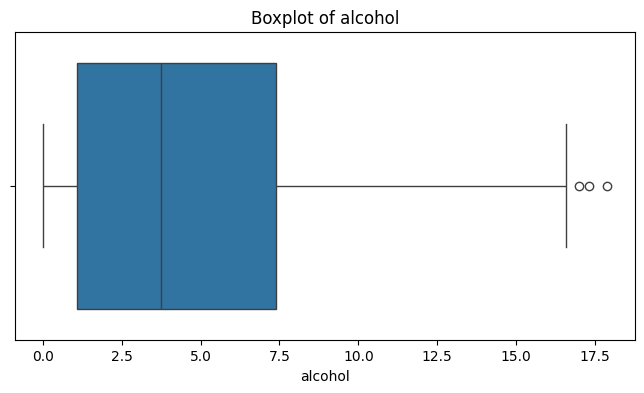

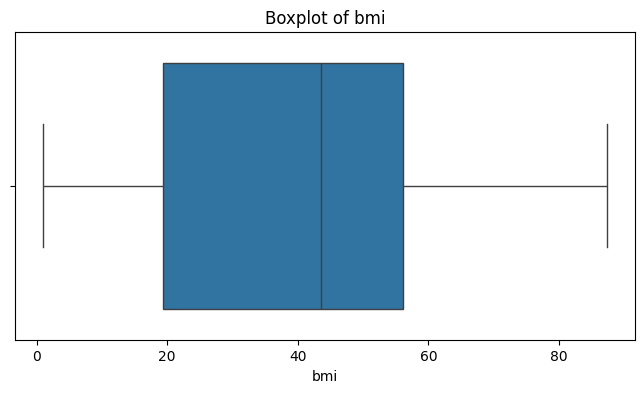

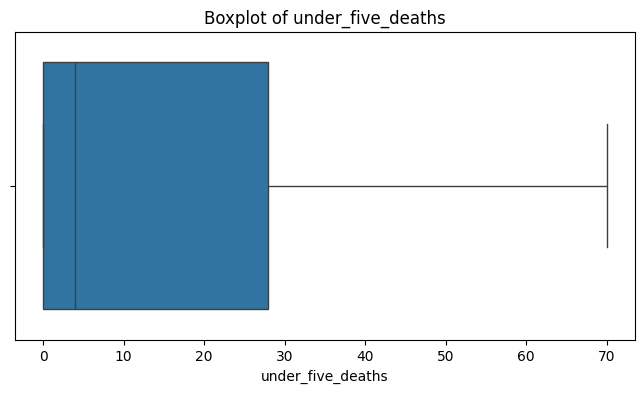

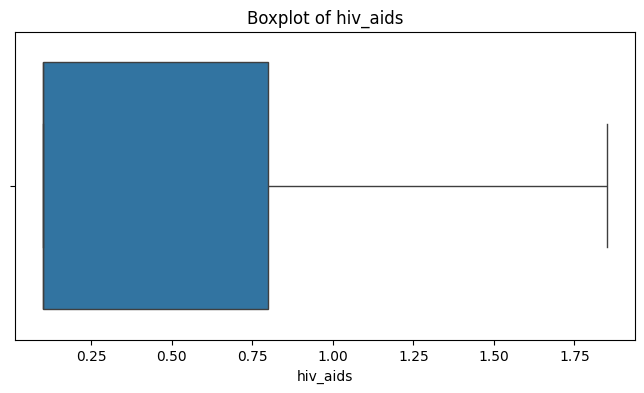

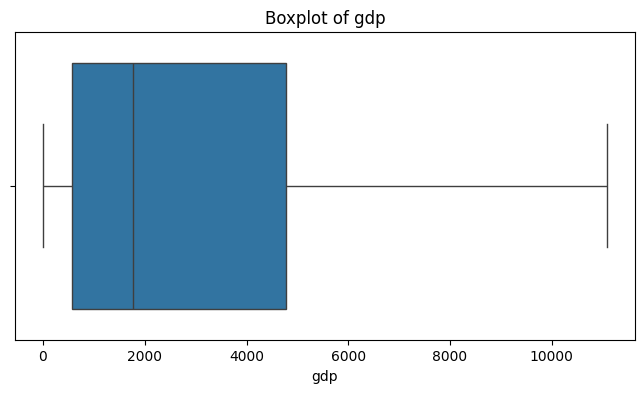

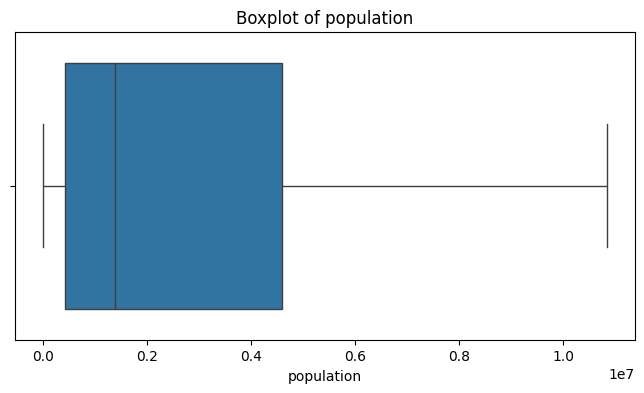

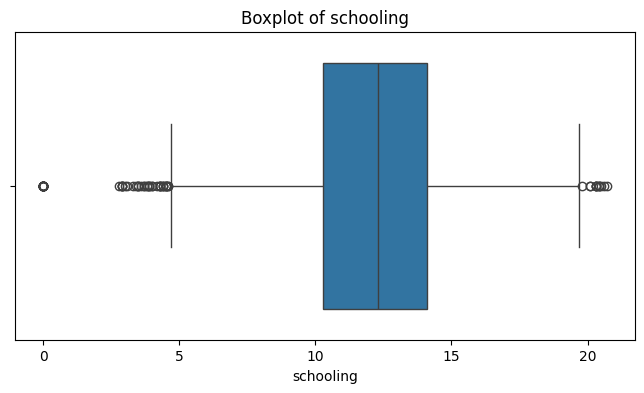

In [148]:
for column in important_numeric:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.show()

### Target Variable : life_expectancy

In [25]:
df["life_expectancy"].value_counts()

life_expectancy
73.0    45
75.0    33
78.0    31
73.6    28
76.0    25
        ..
83.4     1
83.2     1
48.8     1
43.8     1
45.4     1
Name: count, Length: 362, dtype: int64

In [26]:
df["life_expectancy"].describe()

count    2928.000000
mean       69.224932
std         9.523867
min        36.300000
25%        63.100000
50%        72.100000
75%        75.700000
max        89.000000
Name: life_expectancy, dtype: float64

### Distribution of life expectancy

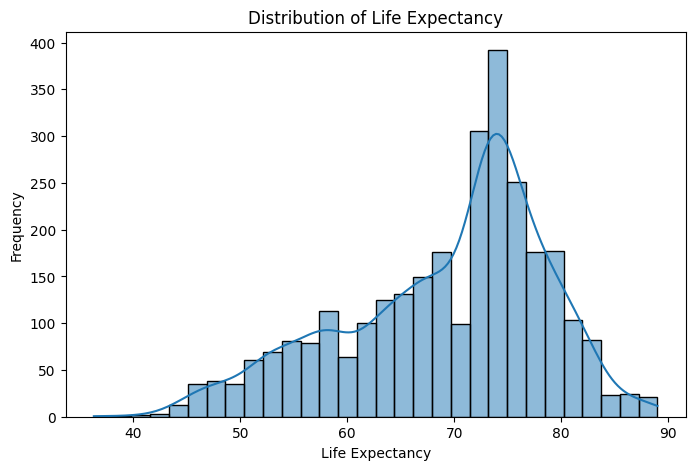

In [27]:
plt.figure(figsize=(8, 5))
sns.histplot(df["life_expectancy"], kde=True)
plt.title("Distribution of Life Expectancy")
plt.xlabel("Life Expectancy")
plt.ylabel("Frequency")
plt.show()

#### This shows how life expectancy is distributed across country-year observations.

### CATEGORICAL EDA

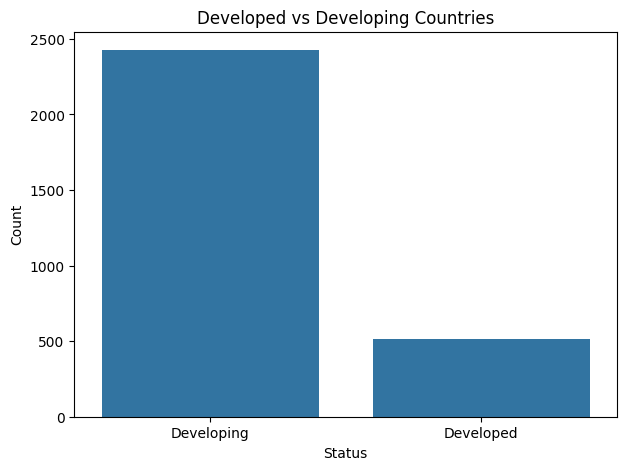

In [28]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="status")
plt.title("Developed vs Developing Countries")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()